In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
# sys.path.insert(0, os.path.abspath('../src'))

from wale.CosmologyModel import Cosmology_function
from wale.CovarianceMatrix import get_covariance
from wale.InitializeVariables import InitialiseVariables
from wale.VarianceCalculator import Variance
from wale.FilterFunctions import top_hat_filter, get_W2D_FL, starlet_filter
from wale.CommonUtils import get_moments, get_l1_from_pdf, compute_sigma_kappa_squared_, compute_sigma_kappa_squared, sigma_kappa_var_from_ccl, build_pk2d_pt
from wale.CriticalPoints import CriticalPointsFinder, find_critical_points_for_cosmo
from wale.ComputePDF import computePDF
from wale.LoadSimulations import get_simulation_l1

import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

import cProfile, pstats
from concurrent.futures import ProcessPoolExecutor
import functools
import copy
# Prepare for multiprocessing
from concurrent.futures import ProcessPoolExecutor
print("Available CPUs:", os.cpu_count())

from scipy.stats import qmc

from scipy.integrate import simpson
from scipy.special import j1

Available CPUs: 128


In [2]:
cosmotable = np.loadtxt('../data/CosmoTable.dat')
cosmotable_om = cosmotable[:,1]
cosmotable_h = cosmotable[:,2]
cosmotable_w0 = cosmotable[:,3]
cosmotable_sig8 =  cosmotable[:,4]
cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    [cosmotable_oc.min(), cosmotable_oc.max()]
])

lh_df = pd.DataFrame(cosmotable[:,1:], columns=["Om", "h", "w0", "sig8", "Oc"])

cosmotable_new = np.loadtxt('../data/lhs_cosmo_samples_halofit.dat')
cosmotable_om_new = cosmotable_new[:,0]
cosmotable_h_new = cosmotable_new[:,1]
cosmotable_w0_new = cosmotable_new[:,2]
cosmotable_sig8_new =  cosmotable_new[:,3]
# cosmotable_oc = cosmotable[:,5]


lh_df_new = pd.DataFrame(cosmotable_new[:,:], columns=["Om", "h", "w0", "sig8"])

# print(lh_df.T)

Parameter bounds: Om, h, w0, sig8
[[ 0.207638  0.392847]
 [ 0.601937  0.798149]
 [-1.390785 -0.616471]
 [ 0.608328  0.8927  ]]
[ 0.207638  0.601937 -1.390785  0.608328]


Text(0, 0.5, '$w_0$')

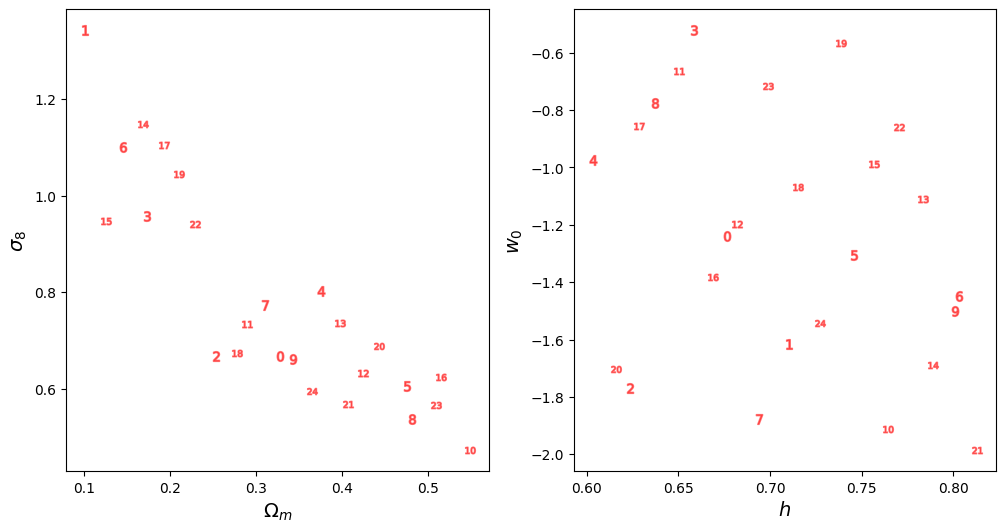

In [3]:
# Get parameter names
param_names = lh_df_new.columns.tolist()

# Get bounds (min and max for each parameter)
param_bounds = np.array([
    [lh_df_new[col].min(), lh_df_new[col].max()] for col in param_names
])
print("Parameter bounds: Om, h, w0, sig8")
print(param_bounds)
print(param_bounds[:,0])
# Number of new samples
n_samples = 100

# Create LHS sampler
sampler = qmc.LatinHypercube(d=len(param_names),scramble=True)

# Generate unit cube samples
lhs_unit = sampler.random(n=n_samples)

# Scale to parameter bounds
lhs_scaled = qmc.scale(lhs_unit, param_bounds[:,0], param_bounds[:,1])

# Convert to DataFrame
lhs_df_100 = pd.DataFrame(lhs_scaled, columns=param_names)

all_lhs_df = pd.concat([lh_df_new, lhs_df_100], ignore_index=True)

marker = np.arange(0, 150, 1)
fig, axs = plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1,2,1)
for i in range(len(lhs_df_100)):
    if i < 25:
        label_red = 'Simulation (red)' if i == 0 else ""
        label_blue = 'New Cosmo (blue)' if i == 0 else ""
        label_green = 'Additional Cosmo (green)' if i == 0 else ""

        # axs[0].scatter(lh_df_new["Om"][i], lh_df_new["sig8"][i], color='blue', marker=f"${marker[i]}$", s=50, label=label_blue)
        axs[0].scatter(lh_df["Om"][i], lh_df["sig8"][i], color='red', marker=f"${marker[i]}$", s=50, alpha=0.5, label=label_red)
        # axs[0].scatter(lhs_df_100['Om'][i], lhs_df_100['h'][i], color='green', marker=f"${marker[i]}$", s=50, label=label_green)

        # axs[1].scatter(lh_df_new["h"][i], lh_df_new["w0"][i], color='blue', marker=f"${marker[i]}$", s=50, label=label_blue)
        axs[1].scatter(lh_df["h"][i], lh_df["w0"][i], color='red', marker=f"${marker[i]}$", s=50, alpha=0.5, label=label_red)
        # axs[1].scatter(lhs_df_100['h'][i], lhs_df_100['w0'][i], color='green', marker=f"${marker[i]}$", s=50, label=label_green)
    # else:
        # axs[0].scatter(lhs_df_100['Om'][i], lhs_df_100['h'][i], color='green', marker=f"${marker[i]}$", s=50, label=label_green)
        # axs[1].scatter(lhs_df_100['h'][i], lhs_df_100['w0'][i], color='green', marker=f"${marker[i]}$", s=50, label=label_green)

# axs[0].legend(loc='upper right', fontsize=10)
# axs[1].legend(loc='upper right', fontsize=10)       
axs[0].set_xlabel(r"$\Omega_m$", fontsize=14)
axs[0].set_ylabel(r"$\sigma_8$", fontsize=14)
axs[1].set_xlabel(r"$h$", fontsize=14)
axs[1].set_ylabel(r"$w_0$", fontsize=14)

Text(0, 0.5, '$w_0$')

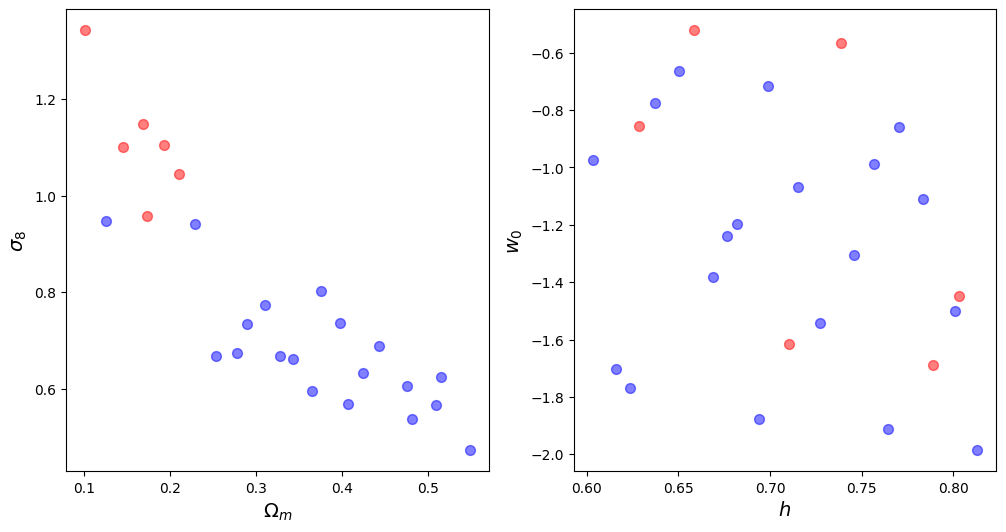

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12, 6))
invalidcosmos = [1,3,6,14,17,19]
plt.subplot(1,2,1)
for i in range(len(lh_df)):
    if i < 25:
        if i in invalidcosmos:
            axs[0].scatter(lh_df["Om"][i], lh_df["sig8"][i], color='red', s=50, alpha=0.5)
            axs[1].scatter(lh_df["h"][i], lh_df["w0"][i], color='red', s=50, alpha=0.5)
        else:
            axs[0].scatter(lh_df["Om"][i], lh_df["sig8"][i], color='blue', s=50, alpha=0.5)
            axs[1].scatter(lh_df["h"][i], lh_df["w0"][i], color='blue', s=50, alpha=0.5)
        
axs[0].set_xlabel(r"$\Omega_m$", fontsize=14)
axs[0].set_ylabel(r"$\sigma_8$", fontsize=14)
axs[1].set_xlabel(r"$h$", fontsize=14)
axs[1].set_ylabel(r"$w_0$", fontsize=14)

In [4]:
import distinctipy

num_colors = 200
distinct_colours = distinctipy.get_colors(num_colors, pastel_factor=0.7)

# 2. Choose a darkening factor (e.g., 0.8 for 20% darker)
darkening_factor = 0.8

# 3. Scale each color’s RGB channels
dark_colours = [
    (r * darkening_factor, g * darkening_factor, b * darkening_factor)
    for r, g, b in distinct_colours
]

# plt.scatter(np.linspace(0, 1, len(distinct_colours)), np.zeros(len(distinct_colours)), c=distinct_colours, s=100)
# # 4. Plot to verify
# plt.figure(figsize=(8, 2))
# plt.scatter(
#     np.linspace(0, 1, num_colors),
#     np.zeros(num_colors),
#     c=dark_colours,
#     s=100
# )
# plt.yticks([])
# plt.xlim(-0.05, 1.05)
# plt.title("Slightly Darkened Palette")
# plt.show() 
    

In [5]:
def get_results(cosmo_index,tomo_bin, edges, centers, snr,theta1,R_pixels, filter_type,nz_file, simulation, variability=False,numberofrealisations=10, dk=0.005, kmin=1e-4, kmax=1.,ngrid_critical=20):
    results={}
    # --- Simulation block ---
    print(f"\n Processing cosmology index: {cosmo_index}")
    if simulation:
        sim_l1_runs_snr, sim_pdf_runs_snr,sim_l1_runs_kappa,sim_pdf_runs_kappa, avg_sim_l1, std_sim_l1, avg_sim_pdf, std_sim_pdf, simvar = \
            get_simulation_l1(
                cosmo_index,
                tomo_bin,
                edges,
                centers,
                snr,
                R_pixels=R_pixels,
                filter_type=filter_type,
                plot=False,
            )
    else:
        sim_l1_runs = sim_pdf_runs = avg_sim_l1 = std_sim_l1 = avg_sim_pdf = std_sim_pdf = simvar = None
        
    if simulation:
        # --- Cosmology parameters ---
        h = lh_df['h'].iloc[cosmo_index]
        Oc = lh_df['Oc'].iloc[cosmo_index]
        Ob = 0.043
        w = lh_df['w0'].iloc[cosmo_index]
        wa = 0.0
        sigma8 = lh_df['sig8'].iloc[cosmo_index]
        Om = lh_df['Om'].iloc[cosmo_index]
    else:
        # --- Cosmology parameters ---
        wa = 0.0
        Ob = 0.043
        # h = lh_df_new['h'].iloc[cosmo_index]
        # Om = lh_df_new['Om'].iloc[cosmo_index]
        # w = lh_df_new['w0'].iloc[cosmo_index]
        # sigma8 = lh_df_new['sig8'].iloc[cosmo_index]
        h = lhs_df_100['h'].iloc[cosmo_index]
        Om = lhs_df_100['Om'].iloc[cosmo_index]
        w = lhs_df_100['w0'].iloc[cosmo_index]
        sigma8 = lhs_df_100['sig8'].iloc[cosmo_index]
        Oc = Om - Ob #lh_df_new['Oc'].iloc[cosmo_index]
    
    
    if variability:
        numberofrealisations = numberofrealisations
    else:
        numberofrealisations = numberofrealisations
        
    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=dk, kmin=kmin, kmax=kmax,
        nz_file=nz_file, variability=variability,
        theta1=theta1, nplanes=7, numberofrealisations=numberofrealisations,
    )
    print("  variables initialized")
    
    if variability:
        PK = variables.cosmo.pnlsamples
        # print(PK)
    else:
        PK = variables.cosmo.pnl
   
    for run in range (numberofrealisations):
        print(" --------------------------------------------------")
        print(f"  Realisation {run+1} of {numberofrealisations}")
        powspec = PK[run] if variability else PK
        # Compute sigma^2 maps
        variance = Variance(variables.cosmo, filter_type=filter_type, pk=powspec)

        f = (variables.lensingweights**2) * np.array([
        variance.get_sig_slice(z, chi*variables.theta1_radian, chi*variables.theta2_radian)
        for z, chi in zip(variables.redshifts, variables.chis)
        ])
        f[0] *= 0.5
        f[-1] *= 0.5
        variables.sigmasq_map = variables.dchi * np.sum(f) 
        print(f"      The ldt variance is: {variables.sigmasq_map}")
        
        # Theory (perturbation) sigma^2
        theory_sigmasq = compute_sigma_kappa_squared(
            theta1, variables.chis, variables.lensingweights,
            variables.redshifts, variables.cosmo.k, powspec,
            filter_type=filter_type, h=h
        )
        print(f"      The perturbation theory variance is: {theory_sigmasq}") 
        
        # pk2d_pt = build_pk2d_pt(variables.cosmo.cosmoccl, scheme="eulerian")
        # theory_sigmasq = sigma_kappa_var_from_ccl(theta1,
        #                      variables.z_nz, variables.n_z,
        #                      variables.cosmo.cosmoccl,
        #                      pk2d_override=pk2d_pt,   # ccl.Pk2D from PT; if None, uses cosmo's default P(k)
        #                      ell=None, ell_min=40, ell_max=1e3, n_ell=400,
        #                      normalize_nz=True,
        #                      extra_window=None     # optional callable: A(ell) to multiply (pixel window, etc.)
        #                      )
        
        # print(f"      The theory sigmasq from ccl is {theory_sigmasq}")
        
        if simulation:
            variables.recal_value = variables.sigmasq_map / simvar[run] #theory_sigmasq
        else:
            variables.recal_value = variables.sigmasq_map / (theory_sigmasq)

        if simulation:
            print(f"       The mean simulation variance is: {np.mean(simvar)}")
            print(f"       The simulation variance for this run is: {simvar[run]}")
        print(f"       The recalibration factor is: {variables.recal_value}")
    
        smallest_positive, largest_negative = find_critical_points_for_cosmo(
            variables,
            variance,
            ngrid_critical=ngrid_critical,
            plot=False,
            min_z=1,
            max_z=3,
            smooth_sigma=0.5,
            parallel=True,
            n_jobs=-1,
            return_mode="derivative", 
        )
        variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)
    
            
        # Compute PDF and L1
        computed_PDF = computePDF(variables, variance, centers, plot_scgf=False)
        pdf_vals, kappa_vals = computed_PDF.pdf_values, computed_PDF.kappa_values
        prediction_l1_kappa = np.abs(kappa_vals) * pdf_vals
        
        pred_stats = get_moments(kappa_vals, pdf_vals)  
        norm_kappa = kappa_vals / np.sqrt(pred_stats[1])  # Normalize by stddev
        prediction_pdf_snr = CubicSpline(norm_kappa, pdf_vals)(snr)
        prediction_l1_snr = CubicSpline(norm_kappa, np.abs(kappa_vals) * pdf_vals)(snr)

        # Store results
                  
        print(f"  predstats: mean: {pred_stats[0]}, variance: {pred_stats[1]}, s3: {pred_stats[2]:.3f}, kurtosis: {pred_stats[3]:.3f}, norm: {pred_stats[4]:.3f}")
        entry = {
            'realisation': run,
            'cosmo_index': cosmo_index,
            'cosmology': {'h': h, 'Oc': Oc, 'Om': Om, 'w': w, 'wa': wa, 'sigma8': sigma8},
            'snr': snr,
            'prediction_l1_snr': prediction_l1_snr,
            'prediction_l1_kappa': prediction_l1_kappa,
            'prediction_pdf_snr': prediction_pdf_snr,
            'prediction_pdf_kappa': pdf_vals,
            'ldt_theory_sigma_sq': variables.sigmasq_map,
            'perturbation_theory_sigma_sq': theory_sigmasq,
            'pred_stats': {
                'mean': pred_stats[0],
                'variance': pred_stats[1],
                's3': pred_stats[2],
                'kurtosis': pred_stats[3],
                'norm': pred_stats[4]
            },   
            'theory_powspec': powspec,    
            'k': variables.cosmo.k,
            'redshifts': variables.redshifts,
        }
        # results[cosmo_index] = entry
        if np.array(pdf_vals).any() < 0:
            print(f"Warning: Negative PDF values encountered in run {run}.")
        if cosmo_index not in results:
            if simulation:
                avg_sim_pdf_kappa = np.mean(sim_pdf_runs_kappa, axis=0)
                avg_sim_l1_kappa = np.mean(sim_l1_runs_kappa, axis=0)
                sim_stats = get_moments(centers, avg_sim_pdf_kappa)
                mean_sim, variance_sim, s3_sim, kurtosis_sim, norm_sim = sim_stats
                print(f"  simstats: mean: {mean_sim}, variance: {variance_sim}, s3: {s3_sim:.3f}, kurtosis: {kurtosis_sim:.3f}, norm: {norm_sim:.3f}")
                residual_kappa = (prediction_l1_kappa - avg_sim_l1_kappa) / (avg_sim_l1_kappa + 1e-10)
                residual_snr = (prediction_l1_snr - avg_sim_l1) / (avg_sim_l1 + 1e-10)
                entry.update({
                    'sim_pdf_runs_snr': sim_pdf_runs_snr,
                    'sim_l1_runs_snr': sim_l1_runs_snr,
                    'sim_pdf_runs_kappa': sim_pdf_runs_kappa,
                    'sim_l1_runs_kappa': sim_l1_runs_kappa,
                    'simvar': simvar,
                    'residual_snr': residual_snr,
                    'residual_kappa': residual_kappa,
                    'sim_stats': {
                        'mean': mean_sim,
                        'variance': variance_sim,
                        's3': s3_sim,
                        'kurtosis': kurtosis_sim,
                        'norm': norm_sim
                    }
                })
            results[cosmo_index] = []

        results[cosmo_index].append(entry)
    return results


In [6]:
results_fin = {}


 Processing cosmology index: 0

Initialised Cosmology:
  h = 0.6766, Oc = 0.2809, Ob = 0.043, w = -1.2376, wa = 0.0, sigma8 = 0.6677
  k-range: [0.001, 0.3] with step dk = 0.0001

Initialising WALE with the following parameters:
   Initialised Variables:
      Source redshift: from nz file
      Number of planes: 7
      Angular scale theta1 (radians): 0.004363323129985824, arcmin: 15.0
      Variability: disabled
  variables initialized
 --------------------------------------------------
  Realisation 1 of 20
 
   Variance module initialized...
      The ldt variance is: 1.2613382974186836e-05
  Computing σ²_κ at θ=15.00 arcmin using ℓ in [1.0, 2000.0]
      The perturbation theory variance is: 1.21476489644692e-05
       The mean simulation variance is: 1.1618193063776906e-05
       The simulation variance for this run is: 1.124988009811097e-05
       The recalibration factor is: 1.121201547410698
   Finding critical points (optimized)...
       Setting ngrid = 40. Increase for accu

/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:22: RuntimeWarning: invalid value encountered in power
  return nu * (1.0 - rho ** (-1.0 / nu))
/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:57: RuntimeWarning: invalid value encountered in sqrt
  R1=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,
/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:63: RuntimeWarning: invalid value encountered in sqrt
  R1=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,
/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:64: RuntimeWarning: invalid value encountered in sqrt
  R2=chi * ((1 + delta1[:, newaxis]) ** 0.5) * theta1,


/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:58: RuntimeWarning: invalid value encountered in sqrt
  R2=chi * ((1 + delta2[:, newaxis]) ** 0.5) * theta2,
/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:69: RuntimeWarning: invalid value encountered in sqrt
  R1=chi * ((1 + delta2[:, newaxis]) ** 0.5) * theta2,
/feynman/home/dap/lcs/vt272285/.conda/envs/wale/lib/python3.12/site-packages/wale/RateFunction.py:70: RuntimeWarning: invalid value encountered in sqrt
  R2=chi * ((1 + delta2[:, newaxis]) ** 0.5) * theta2,


   The variance from PDF is:  1.1399808036317133e-05
  predstats: mean: -4.673580705656485e-06, variance: 1.1399706880973417e-05, s3: -36.933, kurtosis: 0.080, norm: 1.000
 --------------------------------------------------
  Realisation 9 of 20
 
   Variance module initialized...
      The ldt variance is: 1.2613382974186836e-05
  Computing σ²_κ at θ=15.00 arcmin using ℓ in [1.0, 2000.0]
      The perturbation theory variance is: 1.21476489644692e-05
       The mean simulation variance is: 1.1618193063776906e-05
       The simulation variance for this run is: 1.1729538129401712e-05
       The recalibration factor is: 1.0753520586262169
   Finding critical points (optimized)...
       Setting ngrid = 40. Increase for accuracy; runtime ~ O(ngrid^2).
       Smallest positive / largest negative: 2204.2690971821053 / -961.0570170798954
   The variance from PDF is:  1.1733721380129435e-05
  predstats: mean: -8.278385759428669e-07, variance: 1.1733558798648564e-05, s3: -41.561, kurtosis: 0.0

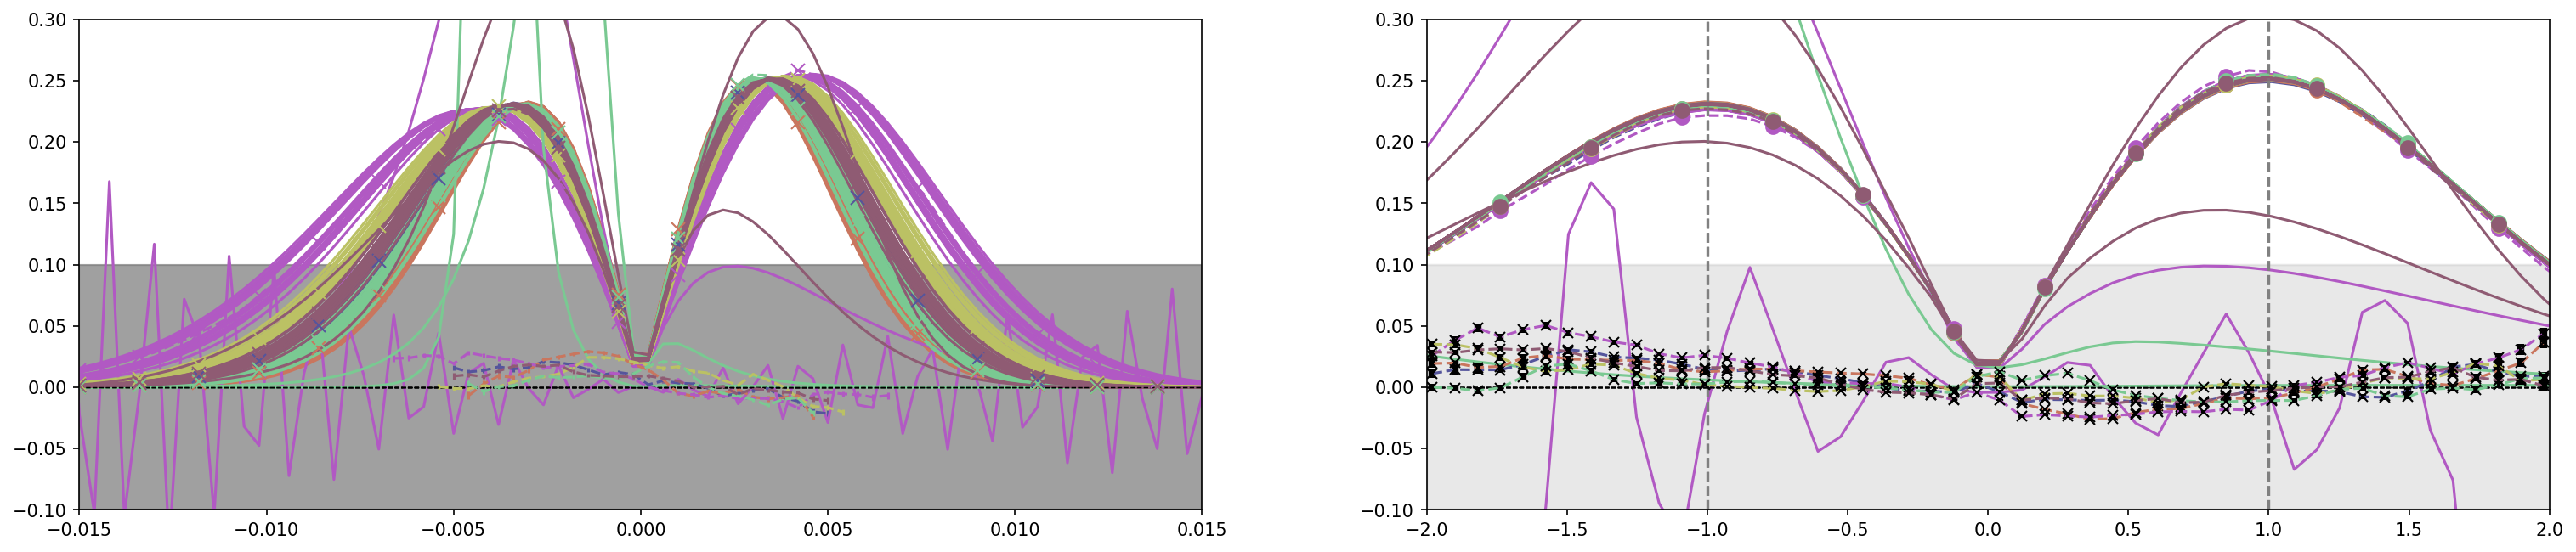

In [7]:
tomo_bin = 5
nz_file = f"../data/nz_arrays_bin{tomo_bin}.npy"

filter_type = 'tophat'

theta1 = 15.0
R_pixels = int(theta1 / 0.5)
edges = np.linspace(-0.02, 0.02, 101)
centers = 0.5 * (edges[:-1] + edges[1:])
snr = np.linspace(-4, 4, 100)

# Flag: include simulation results and variability
simulation = True
variability= False

bad_cosmos = [1,3,6,7,14,17,19]
def main():
    results_ = {}
    fig, axs = plt.subplots(1, 2, figsize=(25, 5),dpi=150)
    for cosmo_index in range(0,10):        
        if cosmo_index in bad_cosmos:
            continue
            
        results_.update(get_results(cosmo_index, tomo_bin, edges, centers, snr, theta1, R_pixels, filter_type, nz_file, simulation=simulation, variability=variability,numberofrealisations=20, dk=0.0001, kmin=1e-3, kmax= .3, ngrid_critical=40))  
        
        [axs[0].plot(centers, results_[cosmo_index][i]['prediction_l1_kappa'], label=f"Cosmo {cosmo_index}", color=dark_colours[cosmo_index]) for i in range(len(results_[cosmo_index]))]
        
        [axs[1].plot(snr, results_[cosmo_index][i]['prediction_l1_snr'], label=f"Cosmo {cosmo_index}", color=dark_colours[cosmo_index]) for i in range(len(results_[cosmo_index]))]

        if simulation:
            axs[0].plot(centers, np.mean(results_[cosmo_index][0]['sim_l1_runs_kappa'], axis=0), color=dark_colours[cosmo_index], linestyle='--', label=f"Sim {cosmo_index}")
            axs[0].errorbar(centers[::4], np.mean(results_[cosmo_index][0]['sim_l1_runs_kappa'], axis=0)[::4], yerr= np.std(results_[cosmo_index][0]['sim_l1_runs_kappa'], axis=0)[::4]/20,color=dark_colours[cosmo_index], fmt='x', markersize=8, label=f"Sim {cosmo_index}")
            residual = results_[cosmo_index][0]['residual_kappa']
            bound = 1.5*(results_[cosmo_index][0]['sim_stats']['variance']**0.5) 
            print(f"The bound is {bound}")
            mask = np.where((centers > -bound) & (centers < bound))
            errbar= np.std(results_[cosmo_index][0]['sim_l1_runs_kappa'], axis=0)/(np.mean(results_[cosmo_index][0]['sim_l1_runs_kappa'], axis=0) + 1e-10)
            print("the shapes are ", (centers[mask])[::4].shape, (residual[mask])[::4].shape, (errbar/20)[::4].shape)
            axs[0].errorbar((centers[mask]), (residual[mask]), yerr= (errbar[mask]/20),linestyle='--', color=dark_colours[cosmo_index], label=f"Residual {cosmo_index}")
            axs[0].set_ylim(-0.1, 0.3)
            axs[0].axhline(0, color='black', linestyle='--', linewidth=0.7)
            axs[0].axhspan(-0.1, 0.1, color='gray', alpha=0.2)
            axs[0].set_xlim(-0.015, 0.015)
            
            axs[1].plot(snr, np.mean(results_[cosmo_index][0]['sim_l1_runs_snr'], axis=0), color=dark_colours[cosmo_index], linestyle='--', label=f"Sim {cosmo_index}")
            axs[1].errorbar(snr[::4], np.mean(results_[cosmo_index][0]['sim_l1_runs_snr'], axis=0)[::4], yerr= np.std(results_[cosmo_index][0]['sim_l1_runs_snr'], axis=0)[::4]/20, color=dark_colours[cosmo_index], fmt='o', markersize=8, label=f"Sim {cosmo_index}")
            residual = results_[cosmo_index][0]['residual_snr']
            bound = 2
            print(f"The bound is {bound}")
            mask = np.where((snr > -bound) & (snr < bound))
            errbar = np.std(results_[cosmo_index][0]['sim_l1_runs_snr'], axis=0)/(np.mean(results_[cosmo_index][0]['sim_l1_runs_snr'], axis=0) + 1e-10)
            axs[1].errorbar(
                snr[mask], 
                residual[mask], 
                yerr=(errbar[mask]/20), 
                linestyle='--', 
                color=dark_colours[cosmo_index],         # line color
                marker='x',                              # add markers
                mfc='red',                               # marker face color
                mec='black',                             # marker edge color
                ecolor='black',                          # error bar color
                elinewidth=4,                          # error bar thickness
                label=f"Residual {cosmo_index}"
            )
            axs[1].set_ylim(-0.1, 0.3)
            axs[1].axhline(0, color='black', linestyle='--', linewidth=0.7)
            axs[1].axhspan(-0.1, 0.1, color='lightgray', alpha=0.1)
            axs[1].set_xlim(-2, 2)
            axs[1].axvline(-1, linestyle='--', color='gray', alpha=0.5)
            axs[1].axvline(1, linestyle='--', color='gray', alpha=0.5)
            # axs[0].legend()
            # axs[1].legend()
    return results_
    
if __name__ == '__main__':
    # key = f"filter{filter_type}_results_{theta1}_tomobin{tomo_bin}_simulation{simulation}_sep" #100newcosmo_
    key = f"filter{filter_type}_results_{theta1}_tomobin{tomo_bin}_simulation{simulation}_sep" #100newcosmo_
    results_fin[key] = main()

# np.save(os.path.join("new_dv/extrabins", key), results_fin[key], allow_pickle=True)


In [8]:
# var_ldt = []
# var_sim = []
# max_ind = 25
# for i in range(0,max_ind):
#     var_ldt.append(results_fin[key][i][0]['ldt_theory_sigma_sq'])
#     # var_sim.append(results_fin[key][i][0]['sim_stats']['variance'])
    
# indexes = np.linspace(1,max_ind,max_ind)
# plt.figure(figsize=(6,6))
# plt.scatter(indexes, var_ldt, c='blue')
# # plt.scatter(indexes, var_sim, c='red')
# plt.xlabel("Cosmology index")
# plt.ylabel("Variance")
# plt.show()



# snr_target = -1.
# tol = 0.05  # how close in SNR you accept, e.g. ±0.05

# cosmo_with_large_resid = []

# for cosmo_index in range(max_ind):
#     snr_arr   = snr      # your SNR array for this cosmology
#     resid_arr = results_fin[key][cosmo_index][0]['residual_snr']   # same shape as snr_arr

#     # Find index closest to snr_target
#     idx = np.argmin(np.abs(snr_arr - snr_target))

#     if np.abs(snr_arr[idx] - snr_target) <= tol:   # within tolerance
#         if resid_arr[idx] > 0.05:
#             cosmo_with_large_resid.append((cosmo_index, snr_arr[idx], resid_arr[idx]))

# print("Cosmologies with residual > 0.06 near SNR = -1.5:")
# for cosmo_index, snr_val, resid_val in cosmo_with_large_resid:
#     print(f"  Cosmology {cosmo_index}: SNR={snr_val:.2f}, residual={resid_val:.3f}")

# excluded = {cidx for cidx, _, _ in cosmo_with_large_resid}

# fig, axs = plt.subplots(1, 3, figsize=(18, 6),dpi=150)
# for i in range(0,25):
#     if np.any(np.array(results_fin[key][i][0]['prediction_l1_snr']) < -0.001):
#         print(f"Warning: Negative prediction_l1_snr values for cosmology index {i}.")
#         continue
#     if i in excluded:
#         continue
#     axs[0].plot(snr, results_fin[key][i][0]['prediction_l1_snr'], label="LDT", color='blue')
#     axs[1].plot(snr, np.mean(results_fin[key][i][0]['sim_l1_runs_snr'], axis=0), label="Simulation", color='red',alpha=0.7)
#     frac_diff = (results_fin[key][i][0]['prediction_l1_snr'] - np.mean(results_fin[key][i][0]['sim_l1_runs_snr'], axis=0))/(np.std(results_fin[key][i][0]['sim_l1_runs_snr'], axis=0))
#     axs[2].plot(snr[20:-50], frac_diff[20:-50],alpha=0.7)
#     axs[2].axhline(0, color='black', linestyle='--', linewidth=0.7)
#     axs[2].axhline(-2)
#     axs[2].axhline(2)
#     axs[2].axhline(-1)
#     axs[2].axhline(1)
#     axs[2].set_ylim(-4,4)
    # plt.xlim(-0.02,0.02)
    # axs.set_ylim(-0.01,0.28)
    # axs[1].set_ylim(0,0.28)
    
# def find_outlier_curves(all_curves, threshold=3.0):
#     """
#     all_curves: array (N_curves, N_bins)
#     threshold: z-score threshold
#     """
#     mean_curve = np.mean(all_curves, axis=0)
#     std_curve  = np.std(all_curves, axis=0)

#     odd_idx = []
#     for i, curve in enumerate(all_curves):
#         z = (curve - mean_curve) / (std_curve + 1e-12)
#         if np.any(np.abs(z) > threshold):
#             odd_idx.append(i)
#     return odd_idx
# # Collect all curves into (N_curves, N_bins)
# all_curves = []
# for key in results_fin:
#     for i in range(len(results_fin[key])):
#         arr = np.asarray(results_fin[key][i][0]['prediction_l1_snr'])
#         all_curves.append(arr)
# all_curves = np.stack(all_curves)

# odd_idx = find_outlier_curves(all_curves, threshold=3.0)
# print("Odd curves indices:", odd_idx)

# plt.figure(figsize=(12,6))
# fig, axs = plt.subplots(1, 1, figsize=(8, 6),dpi=150)
# for i in range(0,100):
#     if np.any(np.array(results_fin[key][i][0]['prediction_l1_snr']) < -0.001):
#         print(f"Warning: Negative prediction_l1_snr values for cosmology index {i}.")
#         continue
#     if i in odd_idx:
#         continue
    
#     axs.plot(snr, results_fin[key][i][0]['prediction_l1_snr'], label="LDT", color='blue')
#     axs.set_ylim(-0.01,0.28)
    

In [9]:
def compare_covariances(pred, sim, label_pred="Prediction", label_sim="Simulation"):
    """
    Quantitative comparison of two covariance matrices.
    
    Parameters
    ----------
    pred : (N,N) array
        Predicted covariance matrix.
    sim : (N,N) array
        Simulated covariance matrix.
    """
    pred = np.asarray(pred)
    sim = np.asarray(sim)
    assert pred.shape == sim.shape, "Matrices must have the same shape"
    
    # 1. Normalize → correlation coefficient matrices
    def to_corr(C):
        d = np.sqrt(np.diag(C))
        d[d==0] = 1e-12
        return C / np.outer(d, d)
    
    corr_pred = to_corr(pred)
    corr_sim = to_corr(sim)
    
    # 2. Eigenvalue spectra
    w_pred = np.linalg.eigvalsh(pred)
    w_sim = np.linalg.eigvalsh(sim)
    
    # 3. Pixel-by-pixel correlation
    flat_corr = np.corrcoef(pred.flatten(), sim.flatten())[0,1]
    
    # 4. Cross sections (main diagonal)
    diag_pred = np.diag(pred)
    diag_sim  = np.diag(sim)
    
    # 5. Residual map
    residual = sim - pred
    
    # ---------------- PLOTS ----------------
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    
    # Covariance maps
    im0 = axs[0,0].imshow(pred, origin="lower", cmap="viridis")
    axs[0,0].set_title(label_pred)
    plt.colorbar(im0, ax=axs[0,0], fraction=0.046)
    
    im1 = axs[0,1].imshow(sim, origin="lower", cmap="viridis")
    axs[0,1].set_title(label_sim)
    plt.colorbar(im1, ax=axs[0,1], fraction=0.046)
    
    im2 = axs[0,2].imshow(residual, origin="lower", cmap="bwr", vmin=-np.max(np.abs(residual)), vmax=np.max(np.abs(residual)))
    axs[0,2].set_title("Residual (Sim - Pred)")
    plt.colorbar(im2, ax=axs[0,2], fraction=0.046)
    
    # Eigenvalue spectra
    axs[1,0].semilogy(np.sort(w_pred)[::-1], 'o-', label=label_pred)
    axs[1,0].semilogy(np.sort(w_sim)[::-1], 'o-', label=label_sim)
    axs[1,0].set_title("Eigenvalue spectra")
    axs[1,0].set_xlabel("Mode index (sorted)")
    axs[1,0].set_ylabel("Eigenvalue")
    axs[1,0].legend()
    
    # Cross-section (diagonal)
    axs[1,1].plot(diag_pred, label=label_pred)
    axs[1,1].plot(diag_sim, label=label_sim)
    axs[1,1].set_title("Main diagonal")
    axs[1,1].set_xlabel("Index")
    axs[1,1].set_ylabel("Variance")
    axs[1,1].legend()
    
    # Correlation matrices
    im3 = axs[1,2].imshow(corr_sim - corr_pred, origin="lower", cmap="bwr", vmin=-1, vmax=1)
    axs[1,2].set_title("Δ Correlation matrix")
    plt.colorbar(im3, ax=axs[1,2], fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # Print scalar metrics
    print("=== Quantitative comparison ===")
    print(f"Pixel-by-pixel correlation: {flat_corr:.3f}")
    print(f"Frobenius norm difference: {np.linalg.norm(sim - pred):.3e}")
    print(f"Relative error (Frob): {np.linalg.norm(sim - pred)/np.linalg.norm(sim):.3e}")
    
    return {
        "corr_pred": corr_pred,
        "corr_sim": corr_sim,
        "eigs_pred": w_pred,
        "eigs_sim": w_sim,
        "diag_pred": diag_pred,
        "diag_sim": diag_sim,
        "flat_corr": flat_corr,
        "residual": residual
    }


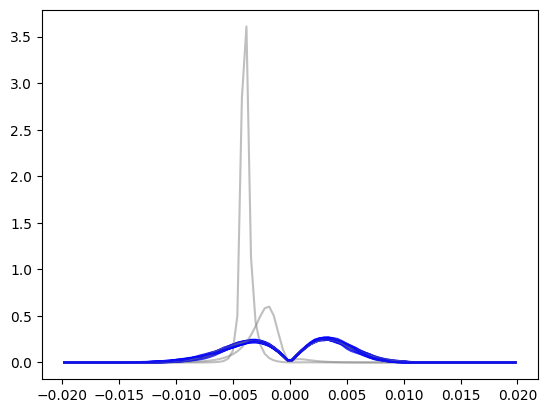

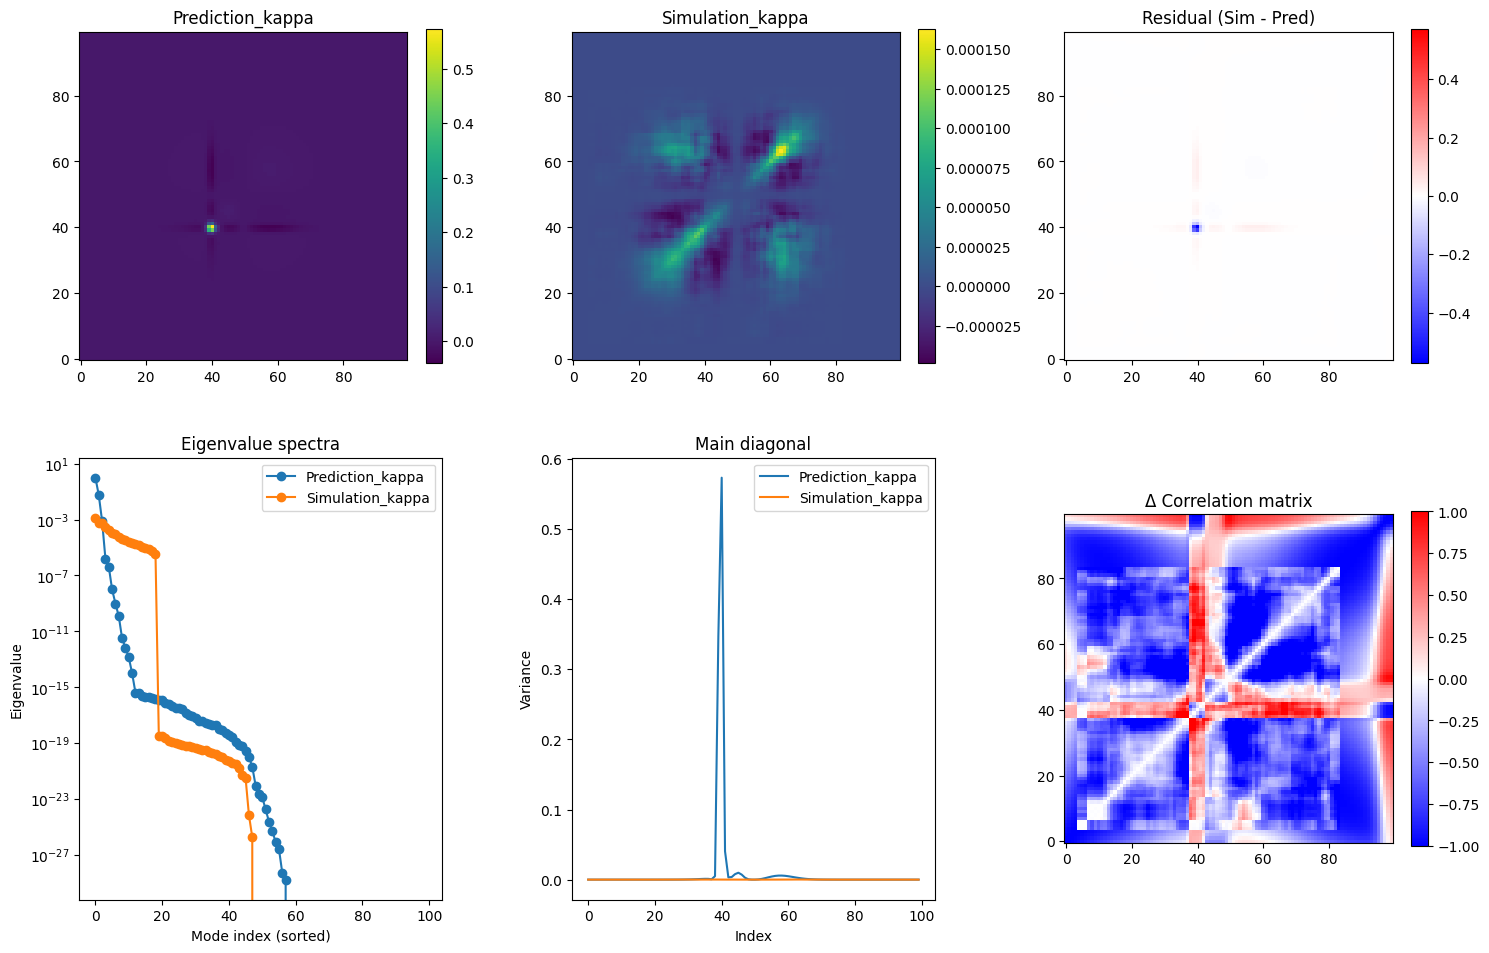

=== Quantitative comparison ===
Pixel-by-pixel correlation: 0.144
Frobenius norm difference: 1.002e+00
Relative error (Frob): 6.390e+02


In [16]:
invalid_idx = [13,5]
def plot_covariance(cos_index):
    pred_l1_array_snr = []
    sim_l1_array_snr = []
    pred_l1_array_kappa = []
    sim_l1_array_kappa = []
    for i in range(len(results_fin[key][cos_index])):
        pred_l1_array_snr.append(results_fin[key][cos_index][i]['prediction_l1_snr'])
        pred_l1_array_kappa.append(results_fin[key][cos_index][i]['prediction_l1_kappa'])
        plt.plot(centers, results_fin[key][cos_index][i]['prediction_l1_kappa'], color='gray', alpha=0.5)
        if simulation:
            sim_l1_array_snr.append(results_fin[key][cos_index][0]['sim_l1_runs_snr'][i])
            sim_l1_array_kappa.append(results_fin[key][cos_index][0]['sim_l1_runs_kappa'][i])
            plt.plot(centers, results_fin[key][cos_index][0]['sim_l1_runs_kappa'][i], color='blue', alpha=0.8)
                
    pred_l1_array_snr = np.array(pred_l1_array_snr)
    sim_l1_array_snr = np.array(sim_l1_array_snr)
    pred_l1_array_kappa = np.array(pred_l1_array_kappa)
    sim_l1_array_kappa = np.array(sim_l1_array_kappa)

    cov_matrix_pred_snr = np.cov(pred_l1_array_snr, rowvar=False)
    cov_matrix_sim_snr = np.cov(sim_l1_array_snr, rowvar=False)

    cov_matrix_pred_kappa = np.cov(pred_l1_array_kappa, rowvar=False)
    cov_matrix_sim_kappa = np.cov(sim_l1_array_kappa, rowvar=False)
    compare_covariances(cov_matrix_pred_kappa, cov_matrix_sim_kappa, label_pred="Prediction_kappa", label_sim="Simulation_kappa")
    # compare_covariances(cov_matrix_pred_snr, cov_matrix_sim_snr, label_pred="Prediction_snr", label_sim="Simulation_snr")

    return

plot_covariance(cos_index=8)


=== Scalar metrics ===
Trace:        Analytic=1.10948e-05, Sim=0.00578097
Determinant:  Analytic=0, Sim=-0
Log-Det:      Analytic=-2693.93, Sim=-2412.75
Frobenius ‖Δ‖: 0.0027064  (relative: 335.68)
Symmetric KL: 9.95547e+10


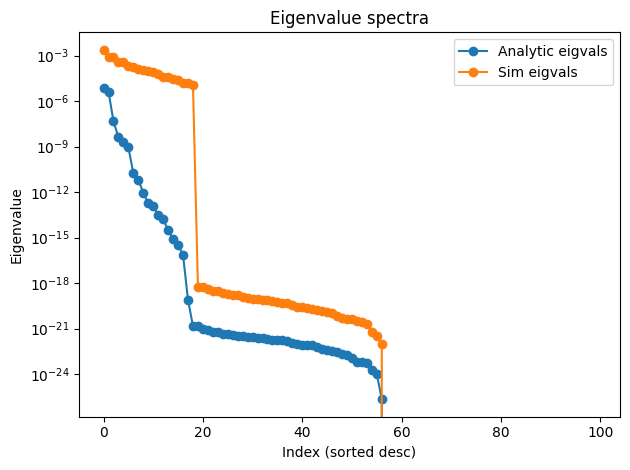

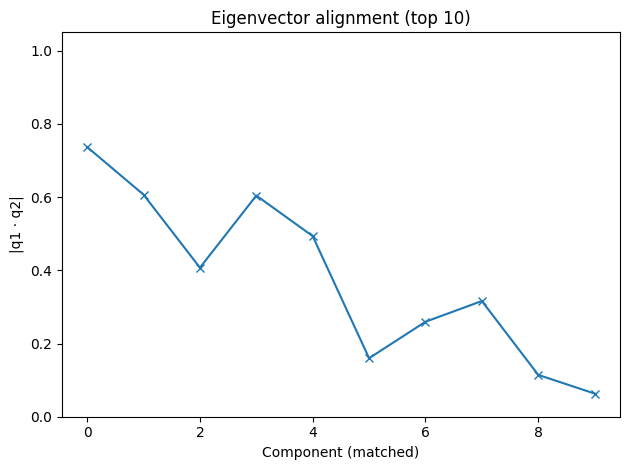

In [86]:
def _symmetrize(C):
    return 0.5 * (C + C.T)

def _eigh_sorted(C):
    """Eigen-decomposition with eigenvalues sorted descending."""
    w, V = np.linalg.eigh(_symmetrize(C))
    idx = np.argsort(w)[::-1]
    return w[idx], V[:, idx]

def _inv_sqrt_psd(C, eps=1e-12):
    """Compute C^{-1/2} for symmetric PSD C via EVD."""
    w, V = np.linalg.eigh(_symmetrize(C))
    w_clamped = np.clip(w, eps, None)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(w_clamped))
    return V @ D_inv_sqrt @ V.T

def _match_eigenvectors(V1, V2):
    """
    Greedy matching of eigenvectors by absolute overlap.
    Returns overlaps in matched order (length n).
    """
    n = V1.shape[1]
    overlaps = np.abs(V1.T @ V2)  # (n x n)
    used_cols = set()
    match = np.zeros(n, dtype=int)
    for i in range(n):
        # pick the best remaining column for row i
        col = np.argmax(np.where(
            np.isin(np.arange(n), list(used_cols), invert=True),
            overlaps[i],
            -1.0
        ))
        # argmax returned an index in 0..n-1 directly because of masking-by-value
        while col in used_cols:
            overlaps[i, col] = -1.0
            col = np.argmax(overlaps[i])
        match[i] = col
        used_cols.add(col)
    matched_overlaps = np.array([overlaps[i, match[i]] for i in range(n)])
    return matched_overlaps, match

def _safe_logdet(C, eps=1e-12):
    w = np.linalg.eigvalsh(_symmetrize(C))
    w = np.clip(w, eps, None)
    return np.sum(np.log(w))

def _symmetric_kl(C1, C2, eps=1e-12):
    """
    Symmetric KL between N(0,C1) and N(0,C2).
    """
    n = C1.shape[0]
    # KL(C1||C2)
    C2_inv = np.linalg.pinv(_symmetrize(C2), rcond=eps)
    C1_inv = np.linalg.pinv(_symmetrize(C1), rcond=eps)
    kl12 = 0.5 * (np.trace(C2_inv @ C1) - n + _safe_logdet(C2) - _safe_logdet(C1))
    kl21 = 0.5 * (np.trace(C1_inv @ C2) - n + _safe_logdet(C1) - _safe_logdet(C2))
    return 0.5 * (kl12 + kl21)

def compare_covariances(C1, C2, labels=("C1", "C2"), top_k=None, show=True):
    """
    Compare two covariance matrices (same shape).
    
    Parameters
    ----------
    C1, C2 : (n,n) arrays
        Covariance matrices with same bins/order.
    labels : tuple(str, str)
        Names used in plots/summary.
    top_k : int or None
        If set, show only the first k eigenpairs for overlaps.
    show : bool
        If True, creates plots.

    Returns
    -------
    summary : dict
        Metrics and arrays for further analysis.
    """
    C1 = _symmetrize(np.asarray(C1))
    C2 = _symmetrize(np.asarray(C2))
    assert C1.shape == C2.shape and C1.ndim == 2 and C1.shape[0] == C1.shape[1]

    n = C1.shape[0]
    if top_k is None or top_k > n:
        top_k = n

    # Eigen stuff
    w1, Q1 = _eigh_sorted(C1)
    w2, Q2 = _eigh_sorted(C2)
    cum1 = np.cumsum(w1) / np.sum(w1)
    cum2 = np.cumsum(w2) / np.sum(w2)

    # Eigenvector alignment (greedy matching by overlap)
    overlaps, match = _match_eigenvectors(Q1[:, :top_k], Q2[:, :top_k])

    # Whitening check: eigs of C1^{-1/2} C2 C1^{-1/2}
    C1_inv_sqrt = _inv_sqrt_psd(C1)
    W = C1_inv_sqrt @ C2 @ C1_inv_sqrt
    wW, _ = np.linalg.eigh(_symmetrize(W))  # should be all ones if C1==C2
    wW_sorted = np.sort(wW)[::-1]

    # Scalar summaries
    fro = np.linalg.norm(C1 - C2, ord="fro")
    fro_rel = fro / max(np.linalg.norm(C1, ord="fro"), 1e-12)
    tr1, tr2 = np.trace(C1), np.trace(C2)
    det1, det2 = np.linalg.det(C1), np.linalg.det(C2)
    logdet1, logdet2 = _safe_logdet(C1), _safe_logdet(C2)
    skl = _symmetric_kl(C1, C2)

    summary = {
        "eigenvalues": {labels[0]: w1, labels[1]: w2},
        "cumulative_variance": {labels[0]: cum1, labels[1]: cum2},
        "eigenvector_overlaps": {
            "overlaps": overlaps,           # length top_k, in [0,1]
            "match_indices": match.tolist() # Q1[:,i] matched to Q2[:,match[i]]
        },
        "whitening_eigs": wW_sorted,        # ≈ 1 if matrices equal
        "metrics": {
            "trace": {labels[0]: tr1, labels[1]: tr2},
            "determinant": {labels[0]: det1, labels[1]: det2},
            "logdet": {labels[0]: logdet1, labels[1]: logdet2},
            "frobenius": fro,
            "frobenius_relative": fro_rel,
            "symmetric_KL": skl
        }
    }

    if show:
        # 1) Eigenvalue spectra (log-scale optional if spans many decades)
        plt.figure()
        plt.plot(w1, marker='o', label=f"{labels[0]} eigvals")
        plt.plot(w2, marker='o', label=f"{labels[1]} eigvals")
        plt.yscale('log')  # comment this out if you prefer linear
        plt.xlabel("Index (sorted desc)")
        plt.ylabel("Eigenvalue")
        plt.title("Eigenvalue spectra")
        plt.legend()
        plt.tight_layout()

        # # 2) Cumulative variance
        # plt.figure()
        # plt.plot(cum1, marker='.')
        # plt.plot(cum2, marker='.')
        # plt.xlabel("Number of components")
        # plt.ylabel("Cumulative variance explained")
        # plt.title("Cumulative variance")
        # plt.legend(labels)
        # plt.tight_layout()

        # 3) Eigenvector overlaps (top_k)
        plt.figure()
        plt.plot(overlaps, marker='x')
        plt.ylim(0, 1.05)
        plt.xlabel("Component (matched)")
        plt.ylabel("|q1 · q2|")
        plt.title(f"Eigenvector alignment (top {top_k})")
        plt.tight_layout()

        # # 4) Whitening eigenvalues
        # plt.figure()
        # plt.plot(wW_sorted, marker='s')
        # plt.axhline(1.0, linestyle='--')
        # plt.xlabel("Index (sorted desc)")
        # plt.ylabel("λ of C1^{-1/2} C2 C1^{-1/2}")
        # plt.title("Whitening check (identity = perfect match)")
        # plt.tight_layout()

        # Print scalar metrics
        print("=== Scalar metrics ===")
        print(f"Trace:        {labels[0]}={tr1:.6g}, {labels[1]}={tr2:.6g}")
        print(f"Determinant:  {labels[0]}={det1:.6g}, {labels[1]}={det2:.6g}")
        print(f"Log-Det:      {labels[0]}={logdet1:.6g}, {labels[1]}={logdet2:.6g}")
        print(f"Frobenius ‖Δ‖: {fro:.6g}  (relative: {fro_rel:.6g})")
        print(f"Symmetric KL: {skl:.6g}")

        plt.show()

    return summary

summary = compare_covariances(cov_matrix_pred, cov_matrix_sim, labels=("Analytic", "Sim"), top_k=10, show=True)

# Access results programmatically:
eigvals_analytic = summary["eigenvalues"]["Analytic"]
overlaps = summary["eigenvector_overlaps"]["overlaps"]
whitening_eigs = summary["whitening_eigs"]
metrics = summary["metrics"]